# HMCode-2020 baryonic feedback model

This notebook explores the [Mead et al. (2020)](https://arxiv.org/abs/2009.01858) baryonic feedback
prescription as implemented in `HMCode-2020` via
 [CAMB](https://camb.readthedocs.io/en/latest/_modules/camb/nonlinear.html) and exposed through the `BaryonsMead20` module in pyCCL.

Unlike baryonic halo models that explicitly decompose matter into multiple components (dark matter, gas, stars) and build the power spectrum from their auto- and cross-correlations, `HMCode` is a phenomenological modification of the nonlinear matter power spectrum. Baryonic effects are encoded through a small number of effective parameters that alter halo structure and clustering in a way calibrated against hydrodynamical simulations.

In `HMCode-2020`, baryonic feedback is incorporated directly into the nonlinear matter power spectrum computation, and its impact can be summarized as a scale- and redshift-dependent boost factor

$B(k,a) = \frac{P^{\rm HMCode}(k,a)}{P^{\rm DMO}(k, a)}$,

defined relative to a dark-matter-only (DMO) baseline computed with otherwise identical settings.

### What this notebook does

Rather than exposing internal halo-model ingredients, this notebook focuses on how the effective `HMCode` feedback parameters translate into changes in the matter power spectrum. We use the `BaryonsMead20` class to construct boost factors and apply them to nonlinear power spectra computed with a CAMB backend.

Specifically, we explore:

- Feedback strength $T_{\rm AGN}$

  The primary baryonic parameter in `HMCode-2020`, controlling the strength
  of AGN feedback. Increasing $T_{\rm AGN}$ generally leads to stronger
  suppression of power on intermediate and small scales.

- Redshift dependence (scale factor $a$)

  We evaluate the boost at several scale factors to illustrate how baryonic suppression evolves with cosmic time.

- Numerical convergence $k_{\max}$

  We vary the maximum wavenumber used in the internal CAMB evaluation to verify that the resulting boost factors are stable and not driven by numerical cutoffs.


Each subplot therefore corresponds to a fixed combination of redshift and numerical settings, while sweeping over the feedback strength parameter. This layout allows us to disentangle physical sensitivity (how baryons suppress or enhance power) from numerical choices required for stable and accurate evaluation.

### Scope and interpretation

This notebook is intended as a diagnostic and visualization tool:

* to illustrate how to access and interpret HMCode parameters within `pyCCL`,
* to build intuition for how HMCode-2020 responds to changes in feedback
strength, and
* to assess the redshift dependence of baryonic suppression,

It does not attempt to interpret HMCode parameters in terms of individual physical components (gas, stars, or profiles), nor does it prescribe a fiducial calibration. Instead, it provides a transparent way to understand how this widely used effective baryonic model modifies the nonlinear matter power spectrum in practice.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmasher as cmr

import pyccl as ccl
from pyccl.baryons import BaryonsMead20


In [2]:
# basic input parameters
cosmo = ccl.CosmologyVanillaLCDM()  # ccl Cosmology object
k_grid = np.logspace(-3, 1.5, 300)  # wavenumber grid; in [1/Mpc]
a_list = np.array([1.0, 0.8, 0.5])  # scale factors grid

kmax_list = [10.0, 20.0, 50.0]  # max wavenumber feedback parameter; in [1/Mpc]
logT_list = [7.2, 7.6, 7.8, 8.0, 8.3]  # feedback parameter; in log10[K]


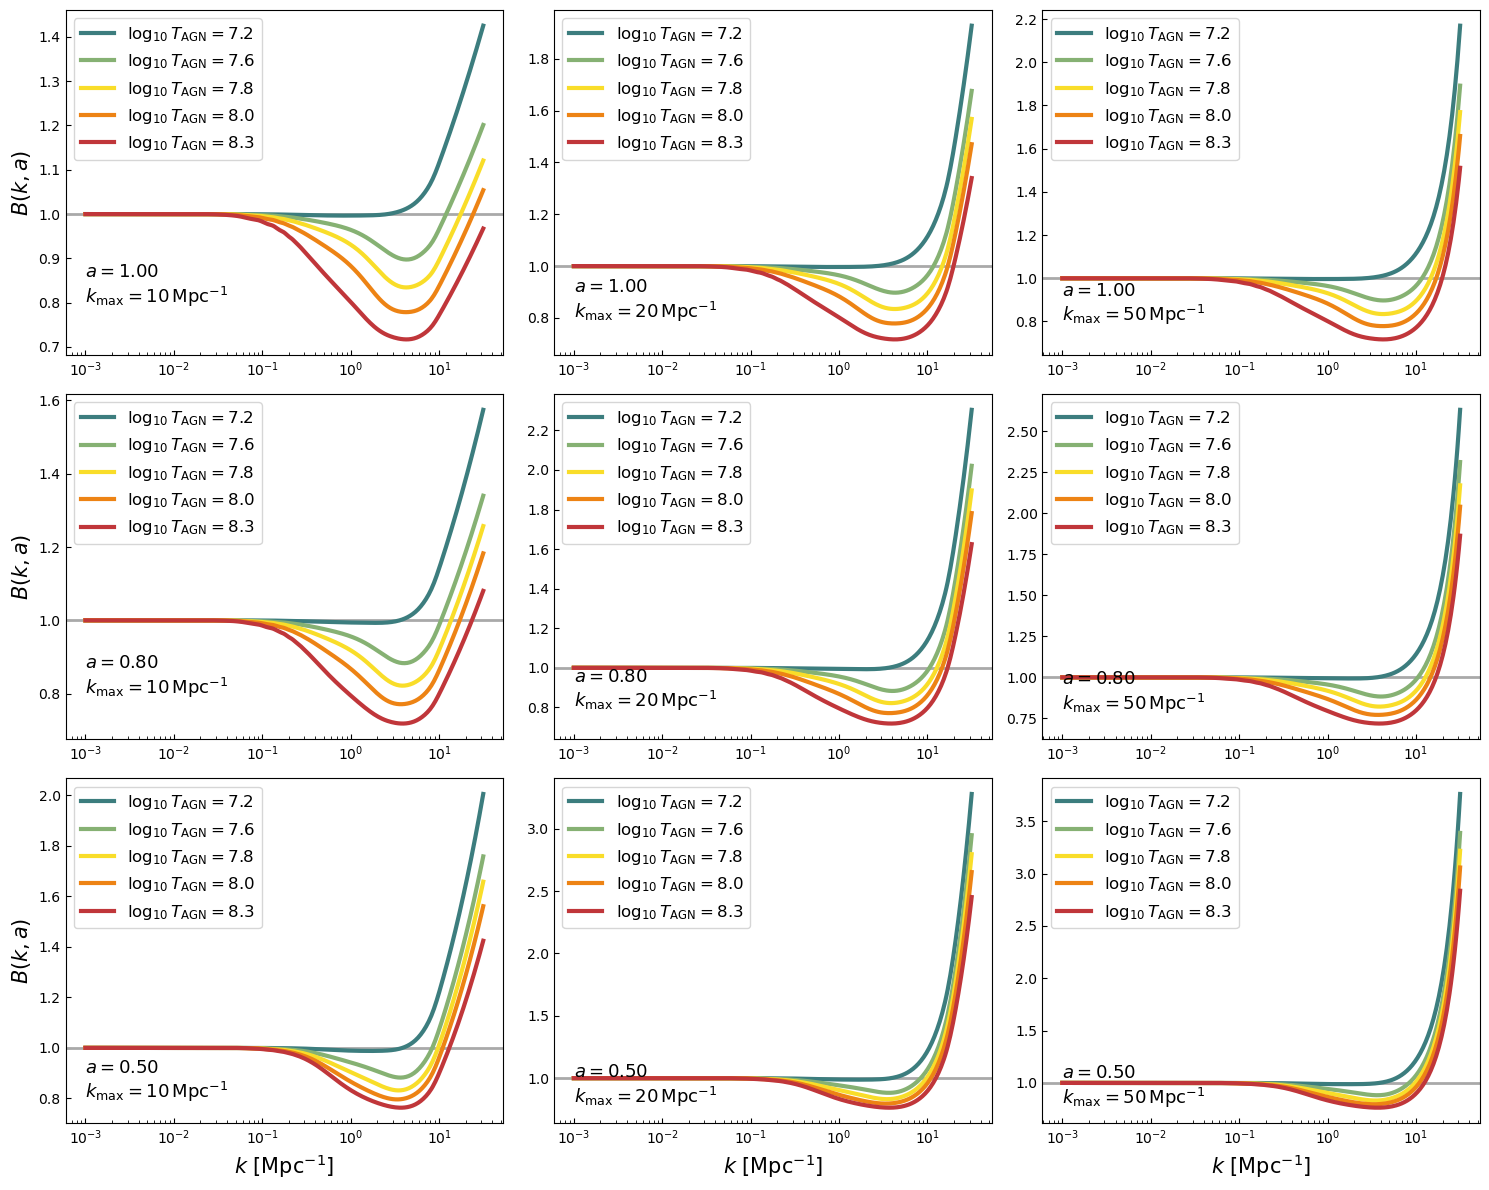

In [3]:
# colors: one per logT curve (consistent across all panels)
colors = cmr.take_cmap_colors(
    "cmr.pride",
    len(logT_list),
    cmap_range=(0.25, 0.75),
)

nrows = len(a_list)
ncols = len(kmax_list)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(5 * ncols, 4 * nrows),
)
axes = np.atleast_2d(axes)

for i, a in enumerate(a_list):
    for j, kmax in enumerate(kmax_list):
        ax = axes[i, j]

        ax.axhline(1.0, lw=2.0, ls="-", c="darkgray")

        for c, logT in zip(colors, logT_list):
            bary = BaryonsMead20(HMCode_logT_AGN=logT, kmax=kmax)
            boost = bary.boost_factor(cosmo, k_grid, a)

            ax.semilogx(
                k_grid, boost,
                color=c,
                lw=3,
                label=rf"$\log_{{10}}T_{{\rm AGN}}={logT}$",
            )

        ax.tick_params(direction="in", which="both")
        ax.legend(fontsize=12, frameon=True, loc=2)
        text = rf"$a={a:.2f}$" + "\n" + rf"$k_{{\max}}={kmax:g}\,\mathrm{{Mpc}}^{{-1}}$"
        ax.text(0.001, 0.8, text, fontsize=13)

# axis labels only on outer edges
for ax in axes[:, 0]:
    ax.set_ylabel(r"$B(k,a)$", fontsize=15)
for ax in axes[-1, :]:
    ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$", fontsize=15)

plt.tight_layout()

# optionally save the figure
# plt.savefig("baryons_mead20.pdf", bbox_inches="tight", dpi=300)

plt.show()
